# Strip Peak Fade — Fading the Market's Best Guess at Terminal

The SR3 strip prices a "peak" contract — the point with the highest implied rate — and
that peak migrates over time. In the easing cycle the trough migrated (Z4→Z5→Z6); in
the hiking cycle the peak migrates (H7→M7→U7). The thesis: the peak/trough carries
embedded premium from bimodal rate-path expectations, and that premium decays.

Two structures:
- **Spread** (sell peak, buy peak+1): 2-leg, 2bp round-trip cost
- **Butterfly** (buy peak−1, sell 2× peak, buy peak+1): 4-leg, 4bp round-trip cost

**Rolling-contract strip** from Jan 2021 through Aug 2026 — the front 8 quarterly
contracts are re-selected at each date as earlier contracts expire.

In [18]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import sys, os, datetime
from pathlib import Path

REPO = Path(r"C:\Users\chris\clee\ARBS-spf")
sys.path.insert(0, str(REPO))
os.environ["ARBS_SUPABASE_ENABLED"] = "0"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

plt.style.use("ggplot")
pylab.rcParams.update({"figure.figsize": (14, 6), "axes.titlesize": "large",
                       "axes.labelsize": "large"})

from RVUtils.StripPeak.strip_builder import build_rolling_strip, rolling_strip_to_daily
from RVUtils.StripPeak.peak_tracker import identify_peak, migration_events
from RVUtils.StripPeak.linear_backtest import (
    backtest_spread_rolling, backtest_butterfly_rolling, summary_stats
)

START = datetime.date(2024, 1, 1)
END = datetime.date(2026, 8, 22)
N_FRONT = 8

print("Fetching rolling strip (first run fetches ~30 contracts from Barchart)...")
rates_wide, active = build_rolling_strip(START, END, N_FRONT, cache=True)
strip_daily = rolling_strip_to_daily(rates_wide, active)
peak = identify_peak(strip_daily)

# map slot indices back to contract names
peak["peak_contract"] = [active.at[d, f"slot_{int(peak.at[d, 'peak_idx'])}"]
                         for d in peak.index]
events = migration_events(peak)

print(f"Strip: {len(rates_wide)} dates, {len(rates_wide.columns)} total contracts")
print(f"Date range: {rates_wide.index[0]} to {rates_wide.index[-1]}")
print(f"Interior peaks: {peak['is_interior'].sum()} / {len(peak)} ({peak['is_interior'].mean():.0%})")
print(f"Migration events: {len(events)}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Fetching rolling strip (first run fetches ~30 contracts from Barchart)...
Strip: 664 dates, 21 total contracts
Date range: 2024-01-02 to 2026-08-21
Interior peaks: 102 / 664 (15%)
Migration events: 26


## 1. The strip and the peak

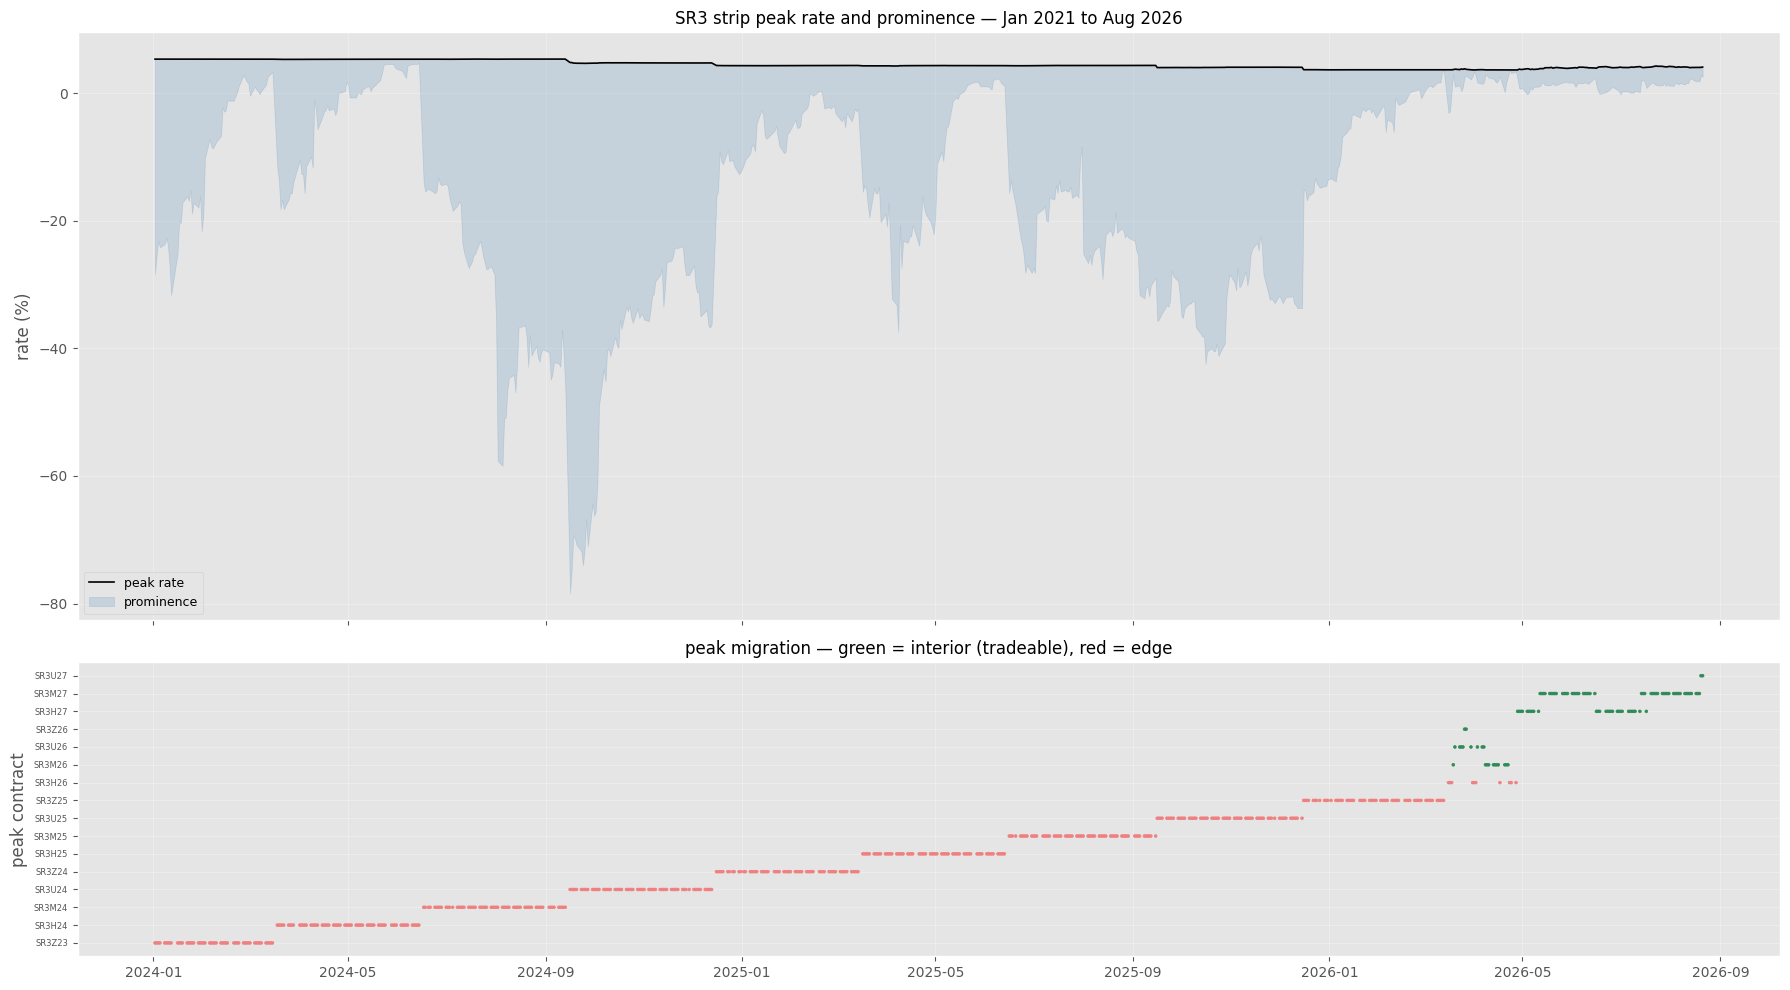


Peak contract distribution (top 15):
peak_contract
SR3U24    64
SR3U25    64
SR3H25    63
SR3H24    63
SR3M25    63
SR3M24    62
SR3Z24    61
SR3Z25    60
SR3Z23    52
SR3M27    50
SR3H27    29
SR3M26    11
SR3H26    10
SR3U26     8
SR3Z26     2


In [19]:
fig, axes = plt.subplots(2, 1, figsize=(18, 10), gridspec_kw={"height_ratios": [2, 1]},
                         sharex=True)

# --- top: peak rate over time ---
ax = axes[0]
dates = [pd.Timestamp(d) for d in peak.index]
ax.plot(dates, peak["peak_rate"].values, lw=1.2, color="black", label="peak rate")
ax.fill_between(dates, peak["peak_rate"].values,
                peak["peak_rate"].values - peak["prominence"].values * 100,
                alpha=0.2, color="steelblue", label="prominence")
ax.set_ylabel("rate (%)")
ax.set_title("SR3 strip peak rate and prominence — Jan 2021 to Aug 2026")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- bottom: which contract is the peak ---
ax = axes[1]
colors = ["seagreen" if peak.iloc[i]["is_interior"] else "lightcoral" for i in range(len(peak))]
# plot the contract name as a categorical
unique_contracts = sorted(peak["peak_contract"].dropna().unique(),
                          key=lambda s: (int(s[4:]), "HMUZ".index(s[3])))
contract_to_y = {c: i for i, c in enumerate(unique_contracts)}
y_vals = [contract_to_y.get(c, -1) for c in peak["peak_contract"]]
ax.scatter(dates, y_vals, c=colors, s=4, zorder=5)
ax.set_yticks(range(len(unique_contracts)))
ax.set_yticklabels(unique_contracts, fontsize=6)
ax.set_ylabel("peak contract")
ax.set_title("peak migration — green = interior (tradeable), red = edge")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPeak contract distribution (top 15):")
print(peak["peak_contract"].value_counts().head(15).to_string())

## 2. Performance — hold=21d

In [33]:
HOLD = 42
COST_SPREAD = 2.0
COST_FLY = 4.0

bt_spread_gross = backtest_spread_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=0.0)
bt_spread_net = backtest_spread_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=COST_SPREAD)
bt_fly_gross = backtest_butterfly_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=0.0)
bt_fly_net = backtest_butterfly_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=COST_FLY)

rows = []
for name, bt in [("spread (gross)", bt_spread_gross), (f"spread (net {COST_SPREAD}bp)", bt_spread_net),
                 ("butterfly (gross)", bt_fly_gross), (f"butterfly (net {COST_FLY}bp)", bt_fly_net)]:
    s = summary_stats(bt)
    rows.append({"book": name, "trades": s["n_trades"], "total_bp": round(s["total_pnl_bp"], 2),
                 "avg_bp": round(s["avg_pnl_bp"], 4), "hit": round(s["hit_rate"], 4),
                 "median_bp": round(s.get("median_pnl_bp", 0), 4),
                 "max_dd_bp": round(s.get("max_dd_bp", 0), 2)})
display(pd.DataFrame(rows).set_index("book"))
print(f"hold = {HOLD}d  |  window: {rates_wide.index[0]} to {rates_wide.index[-1]}")

,trades,total_bp,avg_bp,hit,median_bp,max_dd_bp
book,,,,,,
spread (gross),60,318.25,5.3042,0.6000,1.25,-29.0
spread (net 2.0bp),60,198.25,3.3042,0.4500,-0.75,-88.5
butterfly (gross),57,123.75,2.1711,0.5439,0.50,-24.0
butterfly (net 4.0bp),57,-104.25,-1.8289,0.2982,-3.50,-165.5


hold = 42d  |  window: 2024-01-02 to 2026-08-21


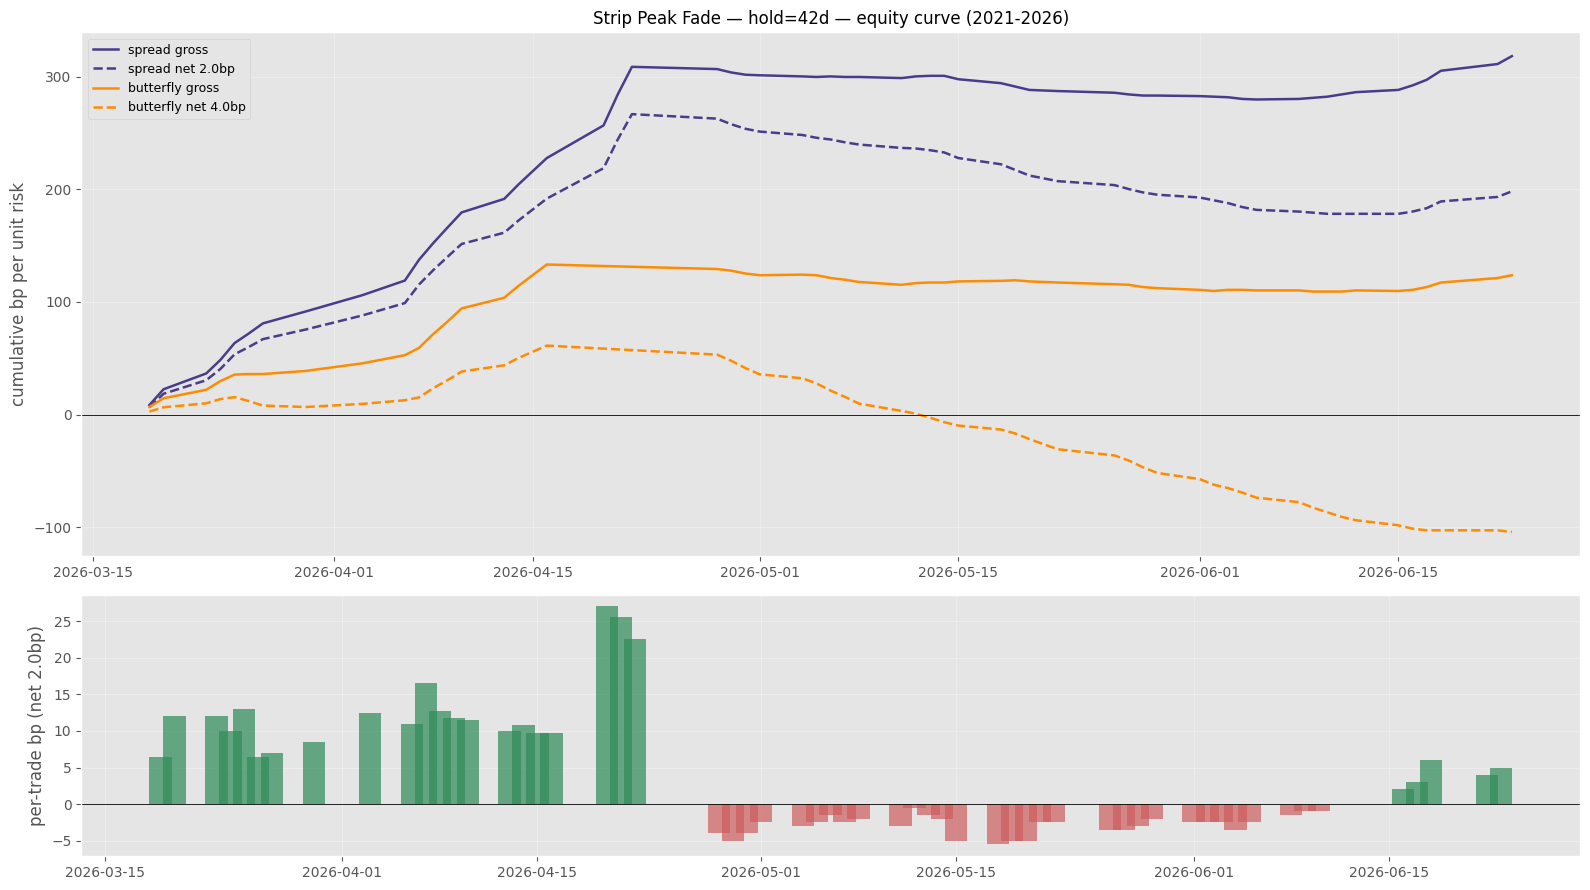

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), gridspec_kw={"height_ratios": [2, 1]})

# --- equity curve ---
ax = axes[0]
for label, bt, color, ls in [
    ("spread gross", bt_spread_gross, "darkslateblue", "-"),
    (f"spread net {COST_SPREAD}bp", bt_spread_net, "darkslateblue", "--"),
    ("butterfly gross", bt_fly_gross, "darkorange", "-"),
    (f"butterfly net {COST_FLY}bp", bt_fly_net, "darkorange", "--"),
]:
    if bt.empty:
        continue
    dates_bt = pd.to_datetime(bt["entry_date"])
    cum = bt["pnl_bp"].cumsum()
    ax.plot(dates_bt.values, cum.values, lw=1.8, color=color, ls=ls, label=label)

ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("cumulative bp per unit risk")
ax.set_title(f"Strip Peak Fade — hold={HOLD}d — equity curve (2021-2026)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- per-trade P&L bars (spread net) ---
ax = axes[1]
if not bt_spread_net.empty:
    dates_bt = pd.to_datetime(bt_spread_net["entry_date"])
    c = ["seagreen" if x > 0 else "indianred" for x in bt_spread_net["pnl_bp"]]
    _span = dates_bt.max() - dates_bt.min()
    _w = _span / min(len(bt_spread_net), 400) if _span and len(bt_spread_net) else pd.Timedelta(days=1)
    ax.bar(dates_bt.values, bt_spread_net["pnl_bp"].values, color=c, width=_w, alpha=0.7)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(f"per-trade bp (net {COST_SPREAD}bp)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Does it clear costs?

,spread_total,butterfly_total
cost_bp_rt,,
0.0,318.2,123.8
0.5,288.2,66.8
1.0,258.2,9.8
1.5,228.2,-47.2
2.0,198.2,-104.2
2.5,168.2,-161.2
3.0,138.2,-218.2


break-even round trip: spread 5.30bp | butterfly 2.17bp


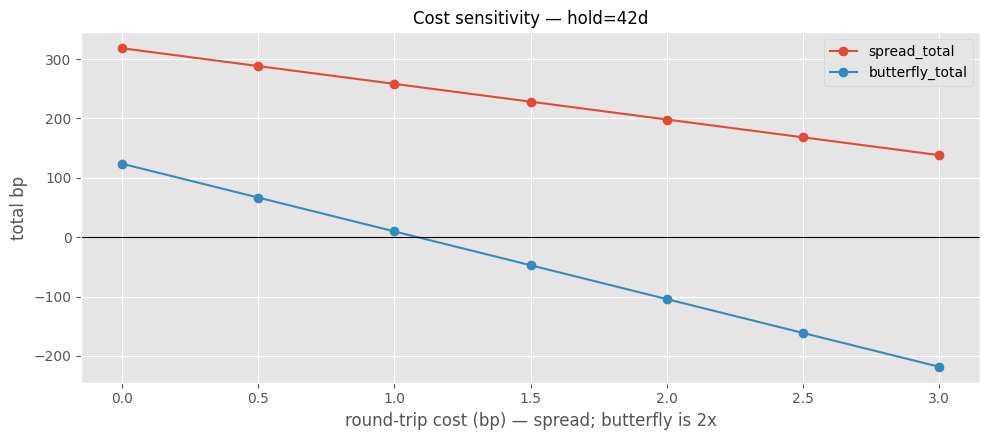

In [35]:
costs_tested = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
rows = []
for cost in costs_tested:
    bt_s = backtest_spread_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=cost)
    bt_f = backtest_butterfly_rolling(rates_wide, active, peak, hold_days=HOLD, cost_bp=cost * 2)
    rows.append({"cost_bp_rt": cost,
                 "spread_total": bt_s["pnl_bp"].sum() if not bt_s.empty else 0,
                 "butterfly_total": bt_f["pnl_bp"].sum() if not bt_f.empty else 0})
cost_df = pd.DataFrame(rows).set_index("cost_bp_rt")
display(cost_df.round(1))

s_be = bt_spread_gross["pnl_bp"].mean() if not bt_spread_gross.empty else 0
f_be = bt_fly_gross["pnl_bp"].mean() if not bt_fly_gross.empty else 0
print(f"break-even round trip: spread {s_be:.2f}bp | butterfly {f_be:.2f}bp")

fig, ax = plt.subplots(figsize=(10, 4.5))
cost_df.plot(marker="o", ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("total bp")
ax.set_xlabel("round-trip cost (bp) — spread; butterfly is 2x")
ax.set_title(f"Cost sensitivity — hold={HOLD}d")
plt.tight_layout()
plt.show()

## 4. Grid over holding periods

=== Spread (net of 2bp) ===


,n_trades,hit_rate,avg_pnl_bp,sharpe,total_pnl_bp,median_pnl_bp,max_dd_bp
hold_days,,,,,,,
5,97,0.1856,-1.6804,-1.2325,-163.00,-1.50,-169.0
10,92,0.3696,-1.1196,-0.6272,-103.00,-0.75,-114.5
21,81,0.5802,0.3395,0.1307,27.50,1.00,-104.0
42,60,0.4500,3.3042,0.8466,198.25,-0.75,-88.5
63,39,0.9231,9.5833,2.5886,373.75,3.00,-3.0



=== Butterfly (net of 4bp) ===


,n_trades,hit_rate,avg_pnl_bp,sharpe,total_pnl_bp,median_pnl_bp,max_dd_bp
hold_days,,,,,,,
5,97,0.0103,-3.6778,-3.7492,-356.75,-3.5,-356.00
10,92,0.0652,-3.1848,-2.3723,-293.00,-3.5,-291.75
21,81,0.2222,-1.9105,-1.0116,-154.75,-2.5,-204.00
42,57,0.2982,-1.8289,-0.8941,-104.25,-3.5,-165.50
63,29,0.0345,-4.5297,-4.0488,-131.36,-4.5,-138.75


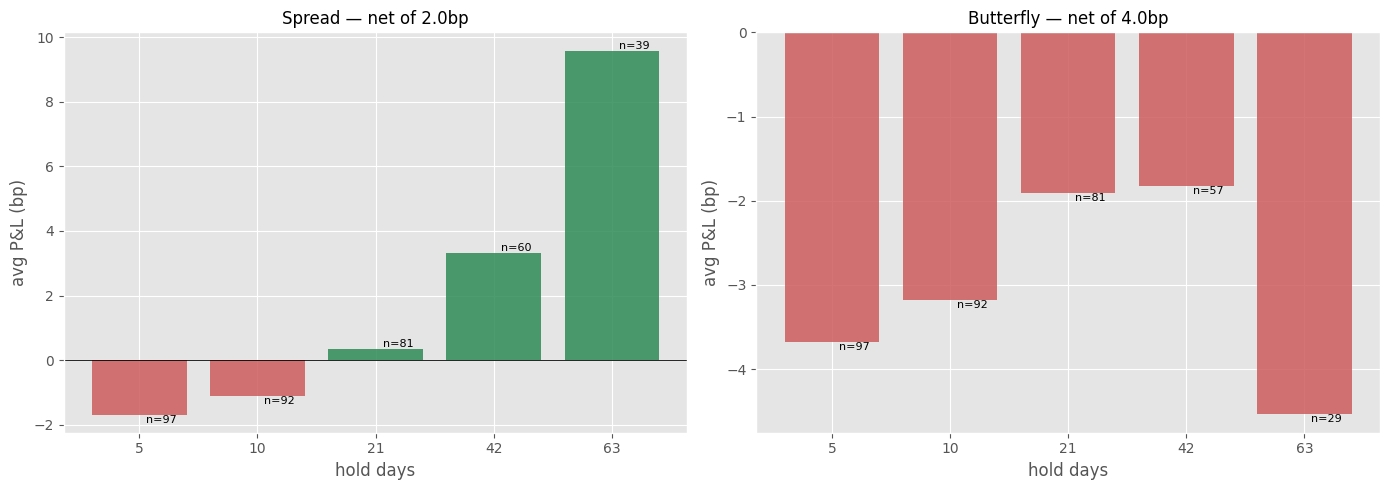

In [36]:
HOLD_GRID = [5, 10, 21, 42, 63]

print("=== Spread (net of 2bp) ===")
spread_rows = []
for hd in HOLD_GRID:
    bt = backtest_spread_rolling(rates_wide, active, peak, hold_days=hd, cost_bp=COST_SPREAD)
    s = summary_stats(bt)
    spread_rows.append({"hold_days": hd, **s})
spread_grid = pd.DataFrame(spread_rows).set_index("hold_days")
display(spread_grid.round(4))

print("\n=== Butterfly (net of 4bp) ===")
fly_rows = []
for hd in HOLD_GRID:
    bt = backtest_butterfly_rolling(rates_wide, active, peak, hold_days=hd, cost_bp=COST_FLY)
    s = summary_stats(bt)
    fly_rows.append({"hold_days": hd, **s})
fly_grid = pd.DataFrame(fly_rows).set_index("hold_days")
display(fly_grid.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, grid, variant, cost in [(axes[0], spread_grid, "Spread", COST_SPREAD),
                                 (axes[1], fly_grid, "Butterfly", COST_FLY)]:
    ax.bar([str(h) for h in HOLD_GRID], grid["avg_pnl_bp"],
           color=["seagreen" if x > 0 else "indianred" for x in grid["avg_pnl_bp"]], alpha=0.85)
    ax.axhline(0, color="k", lw=0.6)
    for i, (h, v) in enumerate(zip(HOLD_GRID, grid["avg_pnl_bp"])):
        ax.text(i, v, f"  n={int(grid.loc[h, 'n_trades'])}", va="bottom" if v > 0 else "top", fontsize=8)
    ax.set_xlabel("hold days")
    ax.set_ylabel("avg P&L (bp)")
    ax.set_title(f"{variant} — net of {cost}bp")
plt.tight_layout()
plt.show()

## 5. By era — easing (2021-2024) vs hiking (2025-2026)

,n_trades,hit_rate,avg_pnl_bp,sharpe,total_pnl_bp,median_pnl_bp,max_dd_bp
era,,,,,,,
2025-2026 (hikes),60,0.45,3.3042,0.8466,198.25,-0.75,-88.5


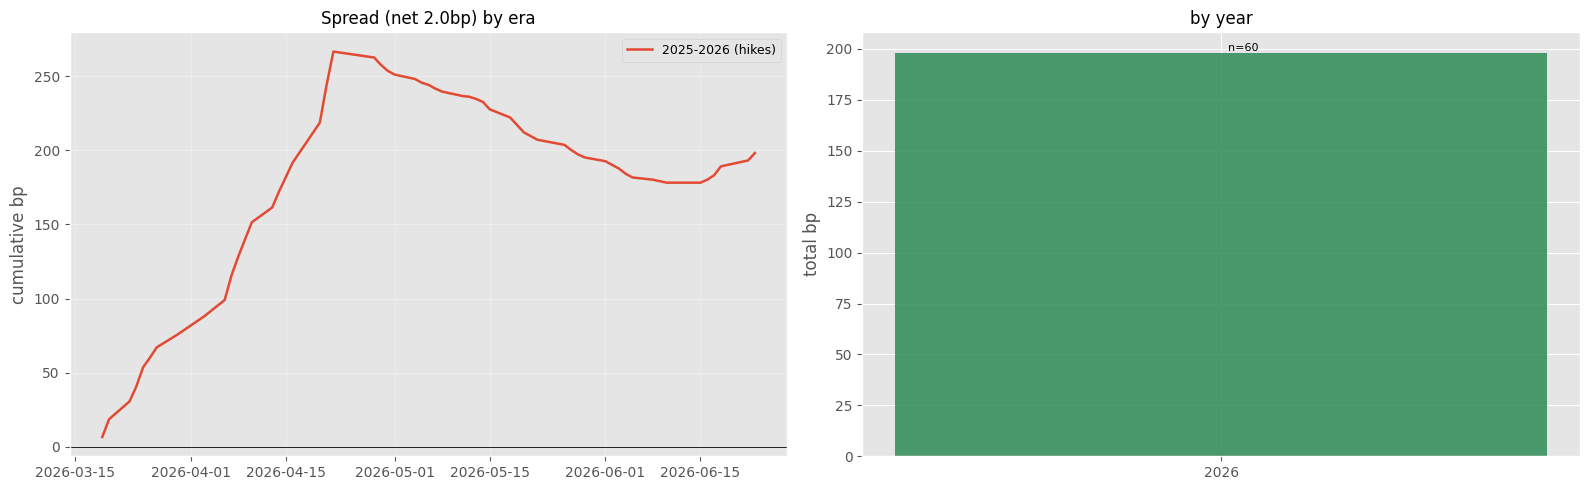

In [37]:
bt = bt_spread_net.copy()
if not bt.empty:
    bt["year"] = pd.to_datetime(bt["entry_date"]).dt.year
    bt["era"] = np.where(bt["year"] <= 2024, "2021-2024 (cuts/hold)", "2025-2026 (hikes)")

    era_stats = []
    for era, sub in bt.groupby("era"):
        s = summary_stats(sub)
        era_stats.append({"era": era, **s})
    display(pd.DataFrame(era_stats).set_index("era").round(4))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for era, sub in bt.groupby("era"):
        sub = sub.sort_values("entry_date")
        axes[0].plot(pd.to_datetime(sub["entry_date"]).values, sub["pnl_bp"].cumsum().values,
                     lw=1.8, label=era)
    axes[0].axhline(0, color="k", lw=0.6)
    axes[0].legend(fontsize=9)
    axes[0].set_ylabel("cumulative bp")
    axes[0].set_title(f"Spread (net {COST_SPREAD}bp) by era")
    axes[0].grid(alpha=0.3)

    yr = bt.groupby("year")["pnl_bp"].agg(["size", "sum", "mean"])
    axes[1].bar(yr.index.astype(str), yr["sum"],
               color=["seagreen" if x > 0 else "indianred" for x in yr["sum"]], alpha=0.85)
    for i, (y, r) in enumerate(yr.iterrows()):
        axes[1].text(i, r["sum"], f"  n={int(r['size'])}", va="bottom" if r["sum"] > 0 else "top", fontsize=8)
    axes[1].axhline(0, color="k", lw=0.6)
    axes[1].set_ylabel("total bp")
    axes[1].set_title("by year")
    plt.tight_layout()
    plt.show()

## 6. Conditioning on prominence

prominence < median             n= 29  avg=+5.65bp  hit=55.2%
prominence >= median            n= 31  avg=+1.11bp  hit=35.5%


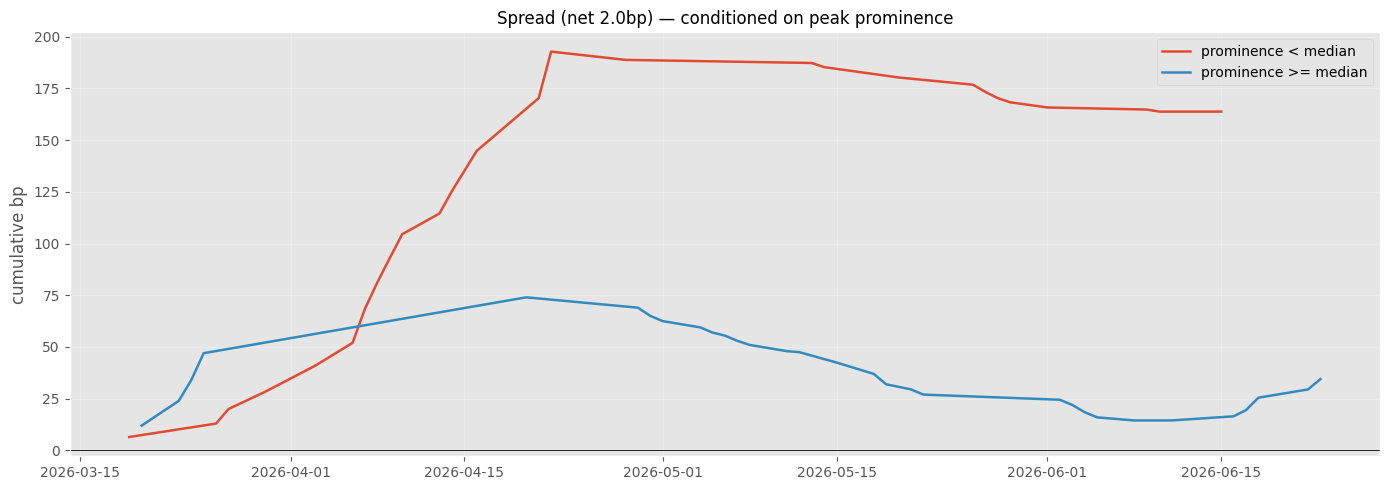

In [38]:
bt = bt_spread_net.copy()
if not bt.empty and "prominence" in bt.columns:
    med_prom = bt["prominence"].median()
    bt["high_prom"] = bt["prominence"] >= med_prom

    for label, sub in bt.groupby("high_prom"):
        tag = "prominence >= median" if label else "prominence < median"
        s = summary_stats(sub)
        print(f"{tag:30s}  n={s['n_trades']:3d}  avg={s['avg_pnl_bp']:+.2f}bp  hit={s['hit_rate']:.1%}")

    fig, ax = plt.subplots(figsize=(14, 5))
    for label, sub in bt.groupby("high_prom"):
        tag = "prominence >= median" if label else "prominence < median"
        sub = sub.sort_values("entry_date")
        ax.plot(pd.to_datetime(sub["entry_date"]).values, sub["pnl_bp"].cumsum().values,
                lw=1.8, label=tag)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel("cumulative bp")
    ax.set_title(f"Spread (net {COST_SPREAD}bp) — conditioned on peak prominence")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Peak contract attribution

,trades,total_bp,avg_bp,hit
peak_contract,,,,
SR3M26,11,157.75,14.3409,1.0000
SR3U26,8,95.50,11.9375,1.0000
SR3Z26,2,13.50,6.7500,1.0000
SR3H27,15,-10.00,-0.6667,0.3333
SR3M27,24,-58.50,-2.4375,0.0417


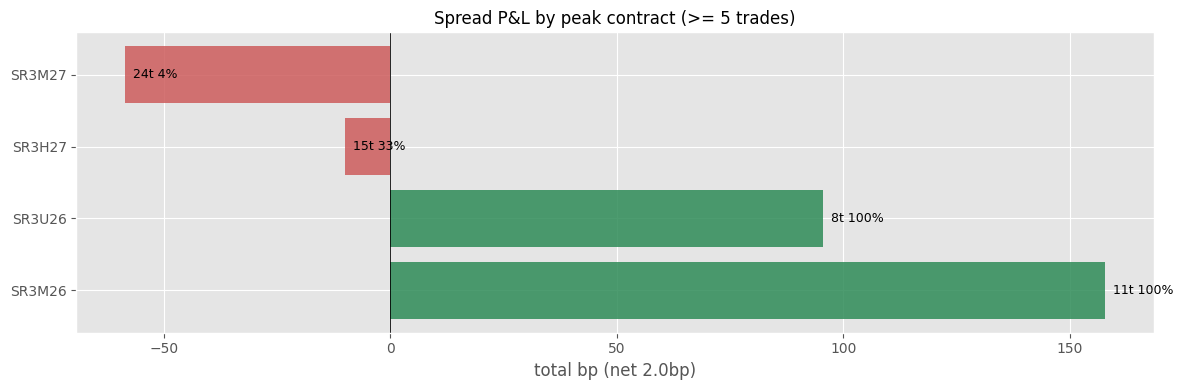

In [39]:
if not bt_spread_net.empty:
    attr = (bt_spread_net.groupby("peak_contract")
            .agg(trades=("pnl_bp", "size"), total_bp=("pnl_bp", "sum"),
                 avg_bp=("pnl_bp", "mean"), hit=("pnl_bp", lambda x: (x > 0).mean()))
            .sort_values("total_bp", ascending=False).round(4))
    display(attr)

    t = attr[attr["trades"] >= 5]
    fig, ax = plt.subplots(figsize=(12, max(4, 0.4 * len(t))))
    ax.barh(t.index, t["total_bp"],
            color=["seagreen" if x > 0 else "indianred" for x in t["total_bp"]], alpha=0.85)
    ax.axvline(0, color="k", lw=0.6)
    ax.set_xlabel(f"total bp (net {COST_SPREAD}bp)")
    ax.set_title("Spread P&L by peak contract (>= 5 trades)")
    for i, (nm, r) in enumerate(t.iterrows()):
        ax.text(r["total_bp"], i, f"  {int(r['trades'])}t {r['hit']:.0%}",
                va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

## 8. Robustness — sign-flip permutation

sign-flip permutation (gross, hold=42d):
  realized mean  +5.304 bp
  null mean      -0.009 +/- 1.238
  two-sided p    0.0000


,trades,total_bp,avg_bp,hit
half,,,,
1st half,30,299.75,9.9917,0.7667
2nd half,30,18.50,0.6167,0.4333


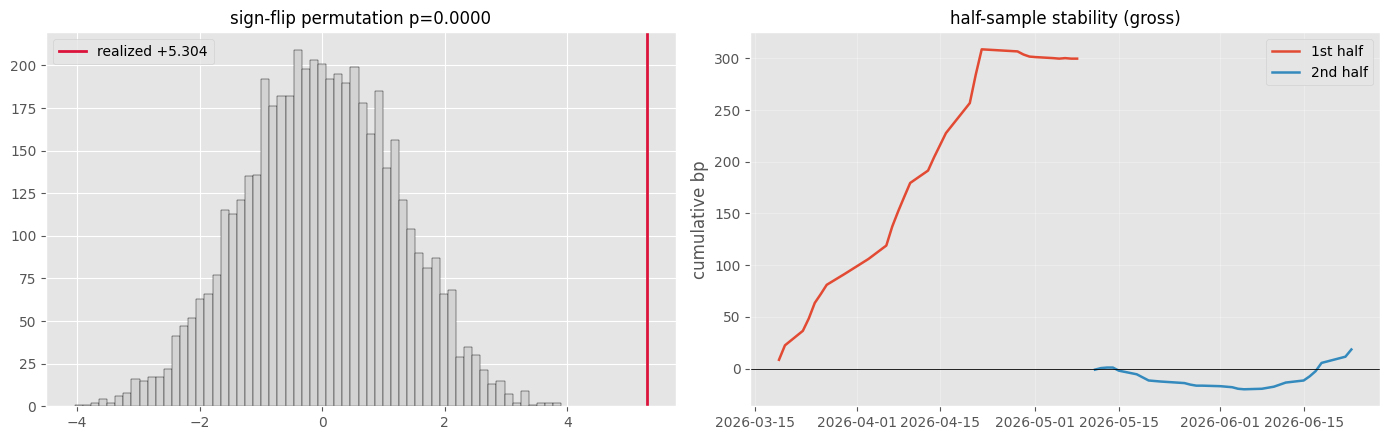

In [40]:
if not bt_spread_gross.empty:
    pnl = bt_spread_gross["pnl_bp"].values
    n = len(pnl)
    realized_mean = pnl.mean()

    rng = np.random.default_rng(42)
    N_PERM = 5000
    perm_means = np.empty(N_PERM)
    for i in range(N_PERM):
        signs = rng.choice([-1, 1], size=n)
        perm_means[i] = (pnl * signs).mean()
    p_value = (np.abs(perm_means) >= abs(realized_mean)).mean()

    print(f"sign-flip permutation (gross, hold={HOLD}d):")
    print(f"  realized mean  {realized_mean:+.3f} bp")
    print(f"  null mean      {perm_means.mean():+.3f} +/- {perm_means.std():.3f}")
    print(f"  two-sided p    {p_value:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].hist(perm_means, bins=60, color="lightgrey", edgecolor="k", lw=0.3)
    axes[0].axvline(realized_mean, color="crimson", lw=2, label=f"realized {realized_mean:+.3f}")
    axes[0].set_title(f"sign-flip permutation p={p_value:.4f}")
    axes[0].legend()

    mid = len(bt_spread_gross) // 2
    h1, h2 = bt_spread_gross.iloc[:mid], bt_spread_gross.iloc[mid:]
    half_rows = []
    for name, sub in [("1st half", h1), ("2nd half", h2)]:
        s = summary_stats(sub)
        half_rows.append({"half": name, "trades": s["n_trades"],
                         "total_bp": round(s["total_pnl_bp"], 2),
                         "avg_bp": round(s["avg_pnl_bp"], 4),
                         "hit": round(s["hit_rate"], 4)})
    display(pd.DataFrame(half_rows).set_index("half"))

    axes[1].plot(pd.to_datetime(h1["entry_date"]).values, h1["pnl_bp"].cumsum().values,
                lw=1.8, label="1st half")
    axes[1].plot(pd.to_datetime(h2["entry_date"]).values, h2["pnl_bp"].cumsum().values,
                lw=1.8, label="2nd half")
    axes[1].axhline(0, color="k", lw=0.6)
    axes[1].set_title("half-sample stability (gross)")
    axes[1].set_ylabel("cumulative bp")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 9. Multi-hold equity curves

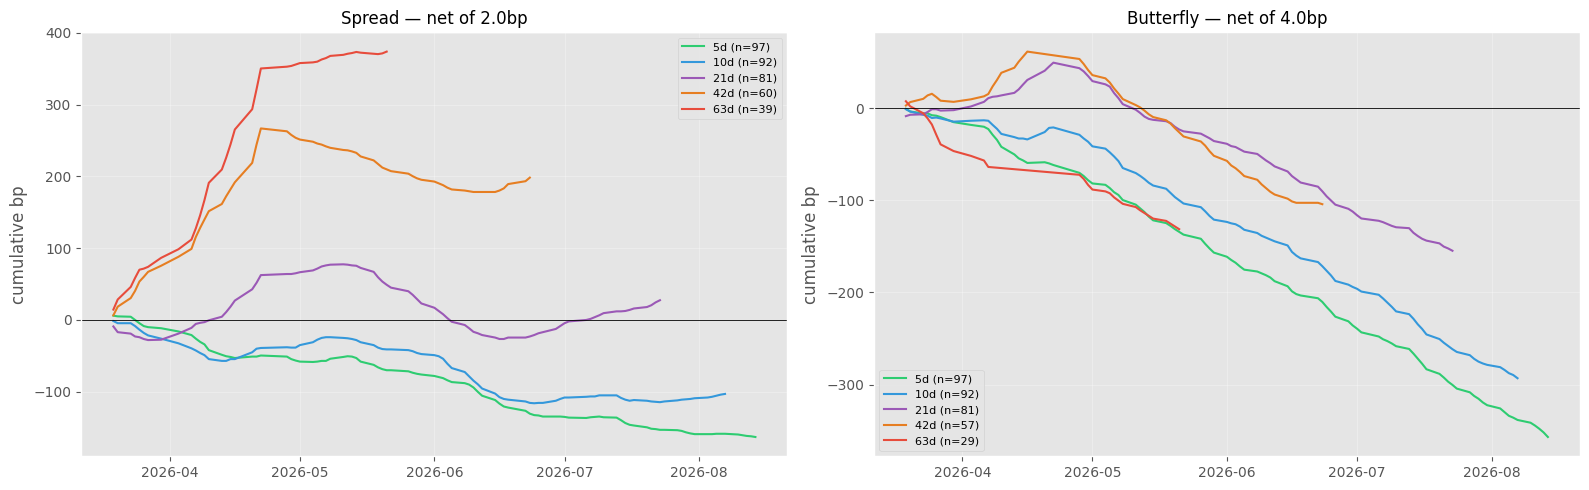

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = ["#2ecc71", "#3498db", "#9b59b6", "#e67e22", "#e74c3c"]

for ax, variant, bt_fn, cost in [
    (axes[0], "Spread", backtest_spread_rolling, COST_SPREAD),
    (axes[1], "Butterfly", backtest_butterfly_rolling, COST_FLY),
]:
    for i, hd in enumerate(HOLD_GRID):
        bt = bt_fn(rates_wide, active, peak, hold_days=hd, cost_bp=cost)
        if bt.empty:
            continue
        dates_bt = pd.to_datetime(bt["entry_date"])
        ax.plot(dates_bt.values, bt["pnl_bp"].cumsum().values,
                lw=1.5, color=palette[i], label=f"{hd}d (n={len(bt)})")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{variant} — net of {cost}bp")
    ax.set_ylabel("cumulative bp")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Summary

In [42]:
s_gross = summary_stats(bt_spread_gross)
s_net = summary_stats(bt_spread_net)

summary = {
    "window": f"{rates_wide.index[0]} to {rates_wide.index[-1]}",
    "trading_days": len(rates_wide),
    "total_contracts_fetched": len(rates_wide.columns),
    "hold_days": HOLD,
    "trades (gross)": s_gross["n_trades"],
    "interior_pct": f"{peak['is_interior'].mean():.0%}",
    "migrations": len(events),
    "gross_total_bp": round(s_gross["total_pnl_bp"], 2),
    "gross_avg_bp": round(s_gross["avg_pnl_bp"], 4),
    "gross_hit": round(s_gross["hit_rate"], 4),
    f"net_total_bp ({COST_SPREAD}bp)": round(s_net["total_pnl_bp"], 2),
    f"net_avg_bp ({COST_SPREAD}bp)": round(s_net["avg_pnl_bp"], 4),
    f"net_hit ({COST_SPREAD}bp)": round(s_net["hit_rate"], 4),
    "sign_flip_p": round(float(p_value), 4) if 'p_value' in dir() else None,
}
for k, v in summary.items():
    print(f"  {k:30s}  {v}")

  window                          2024-01-02 to 2026-08-21
  trading_days                    664
  total_contracts_fetched         21
  hold_days                       42
  trades (gross)                  60
  interior_pct                    15%
  migrations                      26
  gross_total_bp                  318.25
  gross_avg_bp                    5.3042
  gross_hit                       0.6
  net_total_bp (2.0bp)            198.25
  net_avg_bp (2.0bp)              3.3042
  net_hit (2.0bp)                 0.45
  sign_flip_p                     0.0


## 11. Trade log

In [30]:
log = bt_spread_net.copy()
if not log.empty:
    log["cum_bp"] = log["pnl_bp"].cumsum()
    display(log.style.format({
        "entry_spread_bp": "{:+.2f}",
        "exit_spread_bp": "{:+.2f}",
        "pnl_bp": "{:+.3f}",
        "cum_bp": "{:+.2f}",
        "prominence": "{:.4f}"
    }).bar(subset=["pnl_bp"], color=["#d65f5f", "#5fba7d"], align="zero"))

,entry_date,exit_date,peak_contract,next_contract,entry_spread_bp,exit_spread_bp,pnl_bp,prominence,cum_bp
0,2026-03-19,2026-04-17,SR3M26,SR3U26,+0.00,+7.00,-9.000,0.0063,-9.00
1,2026-03-20,2026-04-20,SR3U26,SR3Z26,+0.50,+6.50,-8.000,0.0275,-17.00
2,2026-03-23,2026-04-21,SR3U26,SR3Z26,+3.50,+3.50,-2.000,0.0250,-19.00
3,2026-03-24,2026-04-22,SR3U26,SR3Z26,+0.50,+2.50,-4.000,0.0350,-23.00
4,2026-03-25,2026-04-23,SR3U26,SR3Z26,+1.50,+0.50,-1.000,0.0275,-24.00
5,2026-03-26,2026-04-24,SR3Z26,SR3H27,+0.50,+1.00,-2.500,0.0125,-26.50
6,2026-03-27,2026-04-27,SR3Z26,SR3H27,+1.50,+1.00,-1.500,0.0100,-28.00
7,2026-03-30,2026-04-28,SR3U26,SR3Z26,+2.00,-0.50,+0.500,0.0150,-27.50
8,2026-04-03,2026-05-04,SR3U26,SR3Z26,+1.50,-9.00,+8.500,0.0200,-19.00
9,2026-04-06,2026-05-05,SR3U26,SR3Z26,+1.50,-8.50,+8.000,0.0225,-11.00
